In [101]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import cv2
import hashlib
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [102]:
import os

dataset_path = r"C:\Users\User\ayurvedic-skin-disease-treatment\Data"

print(os.listdir(dataset_path))

['Mild', 'Moderate', 'Severe']


EDA

In [103]:
# This code loads all images with their labels into a DataFrame and shows class counts.
import os
import pandas as pd

classes = sorted(os.listdir(dataset_path))

data = []
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for img in os.listdir(cls_path):
        data.append([os.path.join(cls_path, img), cls])

# Convert the collected data into a Pandas DataFrame
df = pd.DataFrame(data, columns=["image_path", "label"])

print(df["label"].value_counts())
classes = sorted(os.listdir(dataset_path))
print(classes)

label
Moderate    1342
Severe       788
Mild         762
Name: count, dtype: int64
['Mild', 'Moderate', 'Severe']


In [104]:
# This code checks the different image sizes in the dataset and counts how many images have each size.

from PIL import Image
import pandas as pd

sizes = []

for path in df["image_path"]:
    img = Image.open(path)
    sizes.append(img.size)

pd.Series(sizes).value_counts().head()

(1024, 1024)    982
(720, 472)      472
(720, 480)      241
(477, 720)      200
(480, 720)      124
Name: count, dtype: int64

In [105]:
# This code analyzes the brightness levels of images in the dataset.

from PIL import Image
import numpy as np
import pandas as pd

brightness = []

for path in df["image_path"]:
    img = Image.open(path).convert("L")   # convert to grayscale
    brightness.append(np.array(img).mean())

pd.Series(brightness).describe()

count    2892.000000
mean      104.043887
std        25.686854
min        16.155195
25%        87.395862
50%       101.808476
75%       120.867898
max       206.733511
dtype: float64

In [106]:
# This code checks the aspect ratio (width to height) of images in the dataset.

from PIL import Image
import pandas as pd

aspect_ratios = []

for path in df["image_path"]:
    img = Image.open(path)
    w, h = img.size
    aspect_ratios.append(round(w / h, 2))

pd.Series(aspect_ratios).value_counts().head()

1.00    982
1.53    518
1.50    271
0.66    265
0.67    163
Name: count, dtype: int64

In [107]:
import numpy as np

brightness = []

for path in df["image_path"]:
    img = Image.open(path).convert("L")  # grayscale
    brightness.append(np.array(img).mean())

pd.Series(brightness).describe()

count    2892.000000
mean      104.043887
std        25.686854
min        16.155195
25%        87.395862
50%       101.808476
75%       120.867898
max       206.733511
dtype: float64

In [108]:
# This code analyzes the average Red, Green, and Blue color intensity in the images.
r, g, b = [], [], []

for path in df["image_path"]:
    img = Image.open(path).resize((64,64))
    arr = np.array(img)
    r.append(arr[:,:,0].mean())
    g.append(arr[:,:,1].mean())
    b.append(arr[:,:,2].mean())

print("R mean:", np.mean(r))
print("G mean:", np.mean(g))
print("B mean:", np.mean(b))

R mean: 127.38140278205502
G mean: 96.07703599098807
B mean: 83.85088343112466


VISUALIZATION

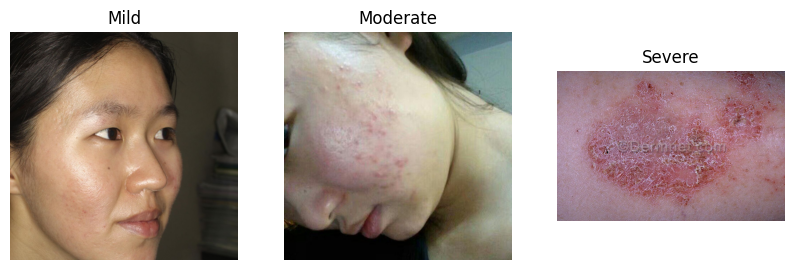

In [109]:
# This code displays one sample image from each class to visually inspect the dataset.
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(10,6))
for i, cls in enumerate(classes):
    img_path = random.choice(df[df["label"] == cls]["image_path"].values)
    img = Image.open(img_path)
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.show()

DATA CLEANING

In [110]:
#Remove Corrupted Images
def remove_corrupted_images(dataset_path):
    removed = 0
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        for img in os.listdir(cls_path):
            try:
                Image.open(os.path.join(cls_path, img)).verify()
            except:
                os.remove(os.path.join(cls_path, img))
                removed += 1
    print("Removed corrupted images:", removed)

remove_corrupted_images(dataset_path)

Removed corrupted images: 0


In [111]:
# This code converts all images to RGB format to ensure consistent input for the model.
def convert_to_rgb(dataset_path):
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            if img.mode != "RGB":
                img.convert("RGB").save(img_path)

convert_to_rgb(dataset_path)

In [112]:
# This code removes duplicate images by comparing their file content using hashes.
hashes = {}
for path in df["image_path"]:
    h = hashlib.md5(open(path,'rb').read()).hexdigest()
    if h in hashes:
        os.remove(path)
    else:
        hashes[h] = path

In [113]:
#Remove non-image files

valid_ext = (".jpg", ".jpeg", ".png")

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for file in os.listdir(cls_path):
        if not file.lower().endswith(valid_ext):
            os.remove(os.path.join(cls_path, file))


In [114]:
# This code converts class names into numerical labels for model training.

classes = sorted(df["label"].unique())

label_map = {cls: i for i, cls in enumerate(classes)}

df["label_encoded"] = df["label"].map(label_map)

print("Label mapping:", label_map)
print(df.head())

Label mapping: {'Mild': 0, 'Moderate': 1, 'Severe': 2}
                                          image_path label  label_encoded
0  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
1  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
2  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
3  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
4  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0


In [115]:
# This code rebuilds the dataset after cleaning and counts the remaining images.

import os
import pandas as pd

data = []

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    
    if os.path.isdir(cls_path):
        for img in os.listdir(cls_path):
            full_path = os.path.join(cls_path, img)
            data.append([full_path, cls])

df = pd.DataFrame(data, columns=["image_path", "label"])

# Recreate label encoding
classes = sorted(df["label"].unique())
label_map = {cls: i for i, cls in enumerate(classes)}
df["label_encoded"] = df["label"].map(label_map)

print("Total images after cleaning:", len(df))
print("Label mapping:", label_map)
print(df.head())

Total images after cleaning: 2892
Label mapping: {'Mild': 0, 'Moderate': 1, 'Severe': 2}
                                          image_path label  label_encoded
0  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
1  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
2  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
3  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
4  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0


In [116]:
# This code detects duplicate images in the dataset by comparing their hash values.
import hashlib

def image_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for path in df["image_path"]:
    h = image_hash(path)
    if h in hashes:
        duplicates.append(path)
    else:
        hashes[h] = path

print("Duplicate images found:", len(duplicates))


Duplicate images found: 0


In [117]:
# This code removes very small images that are not useful for model training.

MIN_SIZE = 100  # pixels
removed = 0

for path in df["image_path"]:
    try:
        img = Image.open(path)
        w, h = img.size
        
        if w < MIN_SIZE or h < MIN_SIZE:
            os.remove(path)
            removed += 1
    except:
        pass

print("Removed small images:", removed)

Removed small images: 0


In [118]:
# This code rebuilds the dataset by collecting updated image paths and labels after cleaning.

data = []

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    
    if os.path.isdir(cls_path):
        for img in os.listdir(cls_path):
            data.append([os.path.join(cls_path, img), cls])

df = pd.DataFrame(data, columns=["image_path", "label"])

# Recreate classes and label encoding
classes = sorted(df["label"].unique())

label_map = {cls: i for i, cls in enumerate(classes)}

df["label_encoded"] = df["label"].map(label_map)

print("Total images:", len(df))
print("Label map:", label_map)
print(df.head())

Total images: 2892
Label map: {'Mild': 0, 'Moderate': 1, 'Severe': 2}
                                          image_path label  label_encoded
0  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
1  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
2  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
3  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0
4  C:\Users\User\ayurvedic-skin-disease-treatment...  Mild              0


preprocessing

In [119]:
# This code splits the dataset into 60% training, 20% validation, and 20% testing while preserving class balance.
from sklearn.model_selection import train_test_split

# Train 60%, Temp 40%
train_df, temp_df = train_test_split(
    df,
    test_size=0.4,
    stratify=df["label_encoded"],
    random_state=42
)

# Temp 40% -> Val 20%, Test 20%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_encoded"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 1735
Validation: 578
Test: 579


In [120]:
# This code loads images, resizes them, and preprocesses them for model training.

import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load and preprocess image
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)

    img = preprocess_input(img)   # correct preprocessing for EfficientNet

    return img, label

In [121]:
# Data augmentation for training images
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

In [122]:
# This code creates TensorFlow datasets for training, validation, and testing with batching and prefetching.
# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values,
     train_df["label_encoded"].values)
)

train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)   # FIRST load image
    .map(lambda x, y: (data_augmentation(x, training=True), y),
         num_parallel_calls=tf.data.AUTOTUNE)               # THEN augment
    .shuffle(len(train_df))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values,
     val_df["label_encoded"].values)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values,
     test_df["label_encoded"].values)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Sanity check
for images, labels in train_ds.take(1):
    print(images.shape, labels.shape)


(32, 224, 224, 3) (32,)


In [123]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["label_encoded"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_encoded"]
)

class_weights = dict(zip(classes, class_weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(1.2654996353026988), np.int64(1): np.float64(0.7184265010351967), np.int64(2): np.float64(1.222692036645525)}


model training


In [124]:
NUM_CLASSES = 3

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(512, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,842,662 (18.47 MB)

 Trainable params: 790,531 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [125]:
# This code compiles the CNN model with optimizer, loss function, and accuracy metric.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [126]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["label_encoded"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_encoded"]
)

class_weights = dict(zip(classes, class_weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(1.2654996353026988), np.int64(1): np.float64(0.7184265010351967), np.int64(2): np.float64(1.222692036645525)}


In [127]:
EPOCHS = 40

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 31s 431ms/step - accuracy: 0.4282 - loss: 1.3471 - val_accuracy: 0.4619 - val_loss: 1.0212 - learning_rate: 3.0000e-04
Epoch 2/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 403ms/step - accuracy: 0.4778 - loss: 1.1386 - val_accuracy: 0.4810 - val_loss: 0.9886 - learning_rate: 3.0000e-04
Epoch 3/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 396ms/step - accuracy: 0.4813 - loss: 1.0783 - val_accuracy: 0.4983 - val_loss: 0.9423 - learning_rate: 3.0000e-04
Epoch 4/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 404ms/step - accuracy: 0.5222 - loss: 1.0172 - val_accuracy: 0.5052 - val_loss: 0.9339 - learning_rate: 3.0000e-04
Epoch 5/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 400ms/step - accuracy: 0.5124 - loss: 0.9723 - val_accuracy: 0.5225 - val_loss: 0.9187 - learning_rate: 3.0000e-04
Epoch 6/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 407ms/step - accuracy: 0.5504 - loss: 0.9247 - val_accuracy: 0.5208 - val_loss: 0.9102 - learning_rate: 3.0000e-04
Epoch 7/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 402ms/step - acc

In [128]:
base_model.trainable = True

for layer in base_model.layers[:200]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)

Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 38s 508ms/step - accuracy: 0.5153 - loss: 0.9746 - val_accuracy: 0.5692 - val_loss: 0.8693
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 486ms/step - accuracy: 0.5476 - loss: 0.9220 - val_accuracy: 0.5536 - val_loss: 0.8862
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 481ms/step - accuracy: 0.5476 - loss: 0.9208 - val_accuracy: 0.5519 - val_loss: 0.8964
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 484ms/step - accuracy: 0.5689 - loss: 0.8848 - val_accuracy: 0.5588 - val_loss: 0.8992
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 481ms/step - accuracy: 0.5366 - loss: 0.9136 - val_accuracy: 0.5675 - val_loss: 0.9020
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 481ms/step - accuracy: 0.5706 - loss: 0.9116 - val_accuracy: 0.5623 - val_loss: 0.9019
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 480ms/step - accuracy: 0.5418 - loss: 0.9216 - val_accuracy: 0.5623 - val_loss: 0.9000
Epoch 8/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 31s 509ms/step - accuracy: 0.5833 - loss: 0.8742 - val_accu

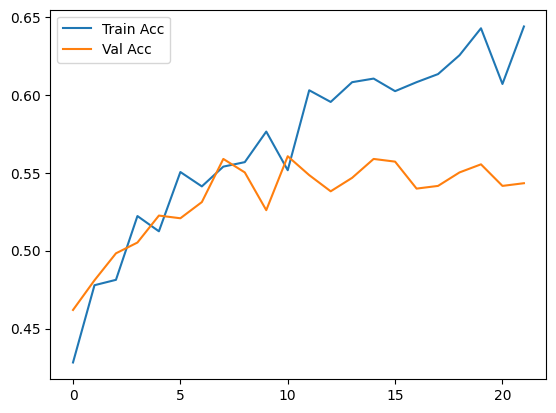

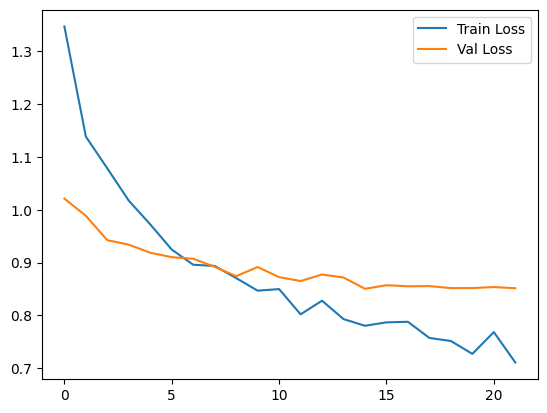

In [129]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()


In [130]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 294ms/step - accuracy: 0.5630 - loss: 0.9223
Test Accuracy: 0.5630397200584412


In [131]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels and predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.argmax(model.predict(test_ds), axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 356ms/step
[[ 87  61   4]
 [ 53 165  51]
 [ 15  69  74]]
              precision    recall  f1-score   support

           0       0.56      0.57      0.57       152
           1       0.56      0.61      0.59       269
           2       0.57      0.47      0.52       158

    accuracy                           0.56       579
   macro avg       0.56      0.55      0.56       579
weighted avg       0.56      0.56      0.56       579



In [132]:
# Save model as .h5 file
model.save("C:\\Users\\User\\ayurvedic-skin-disease-treatment\\severity_model.h5")

In [133]:
from flask import Flask, request
import tensorflow as tf
import numpy as np
from PIL import Image
import os

app = Flask(__name__)

os.makedirs("static/uploads", exist_ok=True)

model = tf.keras.models.load_model(
    "C:\\Users\\User\\ayurvedic-skin-disease-treatment\\severity_model.h5"
)

IMG_SIZE = (224, 224)

def preprocess_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

@app.route("/", methods=["GET", "POST"])
def index():
    prediction = None
    image_path = None

    if request.method == "POST":
        file = request.files["file"]

        if file:
            upload_folder = "static/uploads"
            os.makedirs(upload_folder, exist_ok=True)

            filepath = os.path.join(upload_folder, file.filename)
            file.save(filepath)

            image_path = filepath

            img = preprocess_image(filepath)
            pred = model.predict(img)
            print("Raw prediction:", pred)
            class_index = np.argmax(pred)
            print("Predicted class index:", class_index)

            labels = ["Mild", "Moderate", "Severe"]
            prediction = labels[class_index]

    return f"""
<!DOCTYPE html>
<html>
<head>
<title>Severity Classification</title>
<style>
    body {{
        font-family: Arial;
        background: linear-gradient(135deg, #74ebd5, #ACB6E5);
        display: flex;
        justify-content: center;
        align-items: center;
        height: 100vh;
        margin: 0;
    }}

    .card {{
        background: white;
        padding: 40px;
        border-radius: 15px;
        box-shadow: 0 10px 25px rgba(0,0,0,0.2);
        text-align: center;
        width: 400px;
    }}

    img {{
        margin-top: 20px;
        max-width: 250px;
        border-radius: 10px;
        box-shadow: 0 5px 15px rgba(0,0,0,0.3);
    }}

    button {{
        background-color: #4CAF50;
        color: white;
        border: none;
        padding: 10px 20px;
        border-radius: 5px;
        cursor: pointer;
        font-size: 16px;
    }}

    button:hover {{
        background-color: #45a049;
    }}

    .result {{
        margin-top: 20px;
        font-size: 20px;
        font-weight: bold;
    }}
</style>
</head>

<body>
<div class="card">
    <h1>Ayurvedic Skin Disease Severity Classification</h1>
    <h2>Upload Skin Image</h2>

    <form method="POST" enctype="multipart/form-data">
        <input type="file" name="file" required><br><br>
        <button type="submit">Predict</button>
    </form>

    {f'<img src="/{image_path}">' if image_path else ""}

    <div class="result">
        {f"Predicted Severity: {prediction}" if prediction else ""}
    </div>
</div>
</body>
</html>
"""


if __name__ == "__main__":
    app.run(debug=False)
@app.route("/", methods=["GET", "POST"])
def index():
    prediction = None
    image_path = None

    if request.method == "POST":
        file = request.files["file"]

        if file:
            upload_folder = "static/uploads"
            os.makedirs(upload_folder, exist_ok=True)

            filepath = os.path.join(upload_folder, file.filename)
            file.save(filepath)

            image_path = filepath

            img = preprocess_image(filepath)
            pred = model.predict(img)
            class_index = np.argmax(pred)

            labels = ["Mild", "Moderate", "Severe"]
            prediction = labels[class_index]

    return f"""
<!DOCTYPE html>
<html>
<head>
<title>Severity Classification</title>
<style>
    body {{
        font-family: Arial;
        background: linear-gradient(135deg, #74ebd5, #ACB6E5);
        display: flex;
        justify-content: center;
        align-items: center;
        height: 100vh;
        margin: 0;
    }}

    .card {{
        background: white;
        padding: 40px;
        border-radius: 15px;
        box-shadow: 0 10px 25px rgba(0,0,0,0.2);
        text-align: center;
        width: 400px;
    }}

    img {{
        margin-top: 20px;
        max-width: 250px;
        border-radius: 10px;
        box-shadow: 0 5px 15px rgba(0,0,0,0.3);
    }}

    button {{
        background-color: #4CAF50;
        color: white;
        border: none;
        padding: 10px 20px;
        border-radius: 5px;
        cursor: pointer;
        font-size: 16px;
    }}

    button:hover {{
        background-color: #45a049;
    }}

    .result {{
        margin-top: 20px;
        font-size: 20px;
        font-weight: bold;
    }}
</style>
</head>

<body>
<div class="card">
    <h2>Upload Skin Image</h2>

    <form method="POST" enctype="multipart/form-data">
        <input type="file" name="file" required><br><br>
        <button type="submit">Predict</button>
    </form>

    {f'<img src="/{image_path}">' if image_path else ""}

    <div class="result">
        {f"Predicted Severity: {prediction}" if prediction else ""}
    </div>
</div>
</body>
</html>
"""


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [07/Mar/2026 03:49:39] "GET / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


INFO:werkzeug:127.0.0.1 - - [07/Mar/2026 03:50:02] "POST / HTTP/1.1" 200 -


Raw prediction: [[0.36946967 0.4051225  0.22540785]]
Predicted class index: 1


...

INFO:werkzeug:127.0.0.1 - - [07/Mar/2026 03:50:22] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Mar/2026 03:50:22] "GET /static/uploads/eczema-face-10.jpg HTTP/1.1" 200 -


Raw prediction: [[0.36960366 0.4052661  0.22513029]]
Predicted class index: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


INFO:werkzeug:127.0.0.1 - - [07/Mar/2026 03:50:29] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Mar/2026 03:50:29] "GET /static/uploads/chapped-fissured-feet-14.jpg HTTP/1.1" 200 -


Raw prediction: [[0.36925364 0.40493152 0.22581492]]
Predicted class index: 1


AssertionError: View function mapping is overwriting an existing endpoint function: index